# Semana 7 · Práctica guiada OpenCV
## CADI Percepción Computacional · Experiencia IMAGEN

**Propósito:** comprender cómo una imagen se representa como datos y aplicar operaciones básicas con OpenCV: carga, visualización, conversión de color, redimensionamiento, recorte, filtrado, umbralización, detección de bordes, contornos y guardado de resultados.

**Producto para el informe:** capturas de los resultados, fragmentos de código relevantes y una explicación breve de qué hace cada operación y qué información aporta.

## 0. Instalación y preparación del entorno
Ejecuta esta celda al inicio. En Google Colab se recomienda `opencv-python-headless` porque no requiere interfaz gráfica de escritorio.

In [1]:
!pip -q install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

OpenCV: 4.14.0
NumPy: 2.1.3


## 1. Funciones de apoyo para visualizar imágenes
OpenCV carga las imágenes en formato **BGR**, mientras que Matplotlib espera **RGB**. Por eso usamos una función de apoyo para mostrar correctamente los colores.

In [2]:
def mostrar(imagen, titulo="Imagen", cmap=None):
    """Muestra una imagen OpenCV en Colab/Matplotlib."""
    plt.figure(figsize=(7, 5))
    if imagen.ndim == 2:
        plt.imshow(imagen, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def crear_imagen_de_prueba(ruta="Imagen.jpeg"):
    """Crea una imagen sintética para la práctica si no se sube una imagen propia."""
    img = np.full((420, 640, 3), 245, dtype=np.uint8)
    # Fondo y figuras en BGR
    cv2.rectangle(img, (40, 60), (260, 260), (255, 180, 80), -1)
    cv2.circle(img, (430, 170), 95, (90, 220, 120), -1)
    cv2.rectangle(img, (350, 290), (590, 380), (80, 80, 240), -1)
    cv2.line(img, (20, 390), (620, 20), (20, 20, 20), 5)
    cv2.putText(img, "OpenCV", (70, 340), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (20, 20, 20), 4)
    cv2.imwrite(ruta, img)
    return ruta

## 2. Cargar una imagen
Puedes subir una imagen propia. Si no subes ninguna, el notebook genera una imagen de prueba para asegurar que todos puedan desarrollar la práctica.

Puedes subir una imagen JPG o PNG. Si cancelas, se usará una imagen de prueba.


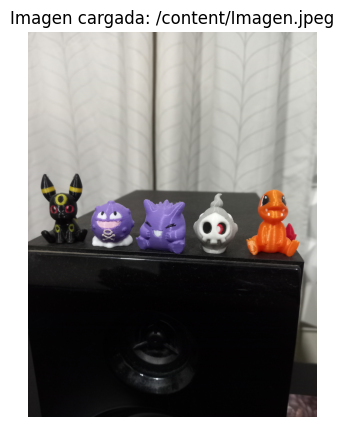

In [11]:
ruta_imagen = "/content/Imagen.jpeg"

try:
    from google.colab import files
    print("Puedes subir una imagen JPG o PNG. Si cancelas, se usará una imagen de prueba.")
    cargados = files.upload()
    if cargados:
        ruta_imagen = list(cargados.keys())[0]
except Exception as e:
    print("No se detectó entorno Colab o no se subió archivo:", e)

if not ruta_imagen:
    ruta_imagen = crear_imagen_de_prueba()

img = cv2.imread("/content/Imagen.jpeg")

if img is None:
    raise ValueError("No se pudo cargar la imagen. Verifica el archivo.")

mostrar(img, f"Imagen cargada: {r"/content/Imagen.jpeg"}")

## 3. Inspección de la imagen como datos
Una imagen se interpreta computacionalmente como una matriz. Observa su tamaño, tipo de dato y valores.

In [12]:
print("Ruta:", "/content/Imagen.jpeg")
print("Forma (alto, ancho, canales):", img.shape)
print("Tipo de dato:", img.dtype)
print("Valor mínimo:", img.min())
print("Valor máximo:", img.max())

alto, ancho = img.shape[:2]
print("Alto:", alto)
print("Ancho:", ancho)
print("Píxel central BGR:", img[alto//2, ancho//2])

Ruta: /content/Imagen.jpeg
Forma (alto, ancho, canales): (4000, 3000, 3)
Tipo de dato: uint8
Valor mínimo: 0
Valor máximo: 255
Alto: 4000
Ancho: 3000
Píxel central BGR: [39 16 24]


### Pregunta para el informe
¿Qué significa que una imagen tenga forma `(alto, ancho, 3)`? ¿Qué representa cada canal?

## 4. Conversión de color
Convertiremos la imagen a RGB para visualizar correctamente y a escala de grises para simplificar el análisis.

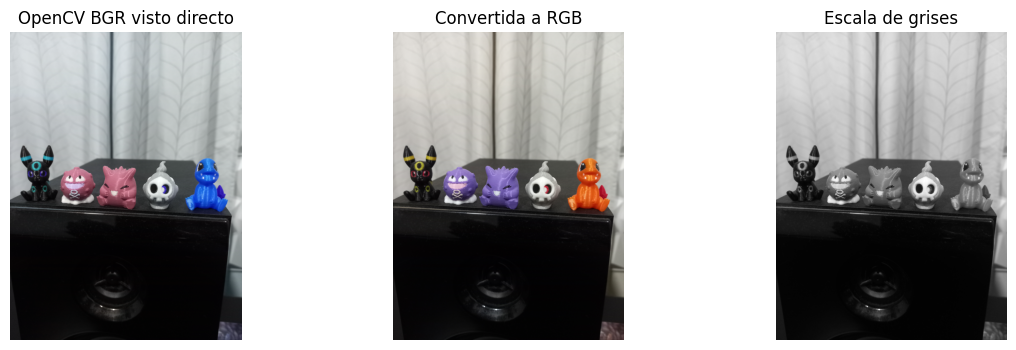

In [13]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)  # Se verá con colores alterados porque está en BGR
plt.title("OpenCV BGR visto directo")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_rgb)
plt.title("Convertida a RGB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gris, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")
plt.show()

## 5. Redimensionamiento y recorte
Estas operaciones permiten preparar la imagen para un modelo o analizar una región específica.

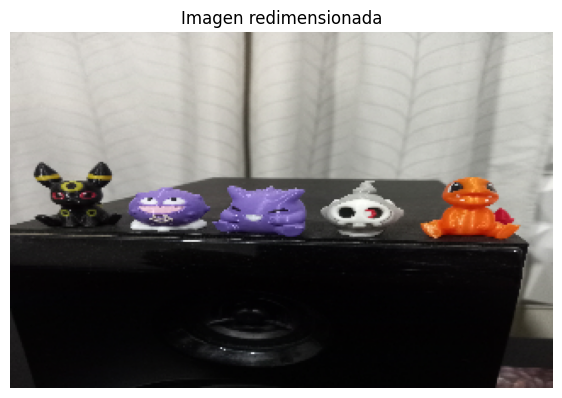

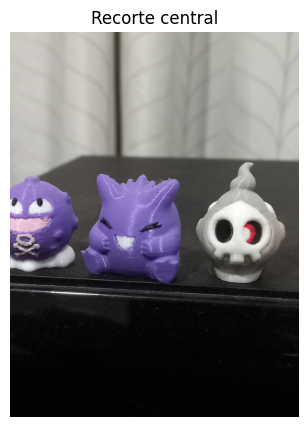

Original: (4000, 3000, 3)
Redimensionada: (210, 320, 3)
Recorte: (2000, 1500, 3)


In [14]:
redimensionada = cv2.resize(img, (320, 210))

# Recorte: zona central
h, w = img.shape[:2]
y1, y2 = int(h*0.25), int(h*0.75)
x1, x2 = int(w*0.25), int(w*0.75)
recorte = img[y1:y2, x1:x2]

mostrar(redimensionada, "Imagen redimensionada")
mostrar(recorte, "Recorte central")

print("Original:", img.shape)
print("Redimensionada:", redimensionada.shape)
print("Recorte:", recorte.shape)

## 6. Filtrado y reducción de ruido
Los filtros suavizan la imagen y pueden ayudar antes de detectar bordes o regiones.

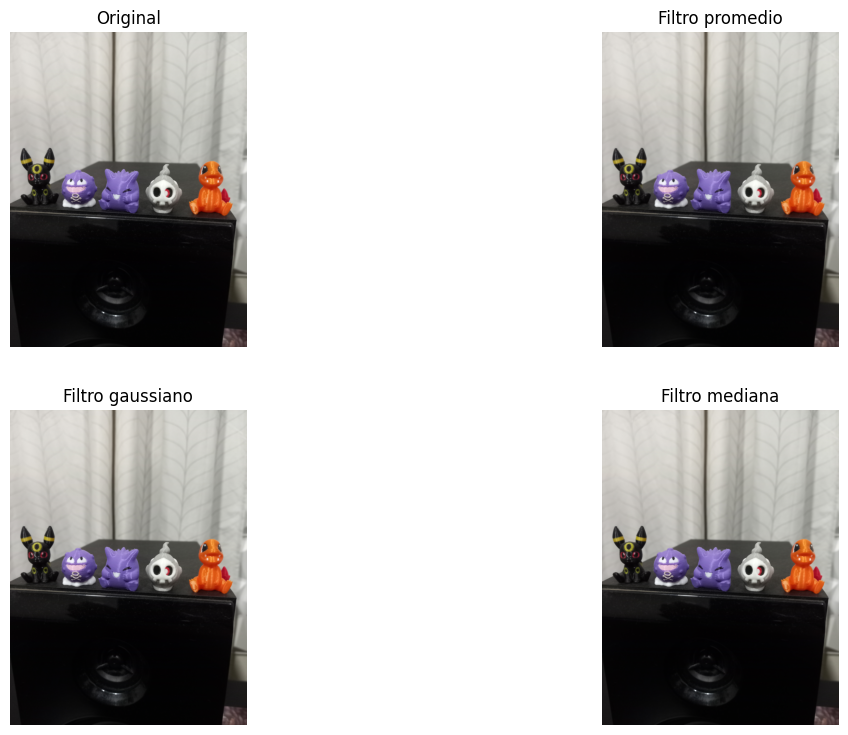

In [15]:
blur_promedio = cv2.blur(img, (7, 7))
blur_gaussiano = cv2.GaussianBlur(img, (7, 7), 0)
blur_mediana = cv2.medianBlur(img, 7)

plt.figure(figsize=(14, 9))
for i, (im, titulo) in enumerate([
    (img, "Original"),
    (blur_promedio, "Filtro promedio"),
    (blur_gaussiano, "Filtro gaussiano"),
    (blur_mediana, "Filtro mediana")
], 1):
    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
plt.show()

## 7. Umbralización y detección de bordes
Estas operaciones resaltan zonas relevantes. La umbralización separa intensidades; Canny detecta cambios fuertes en la imagen.

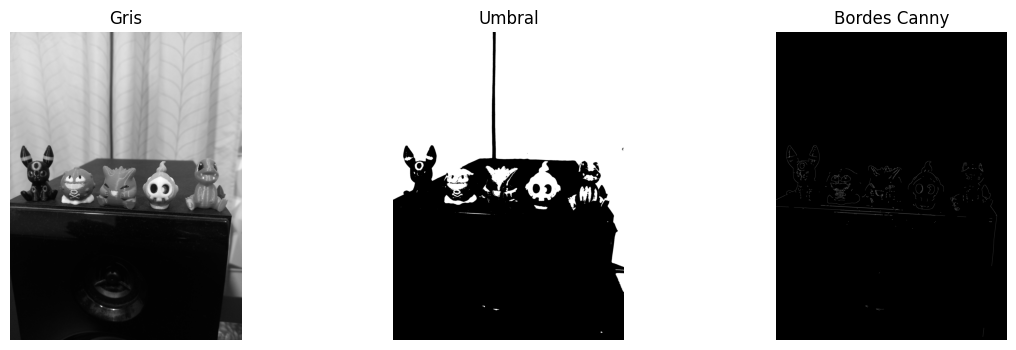

In [16]:
gris_suave = cv2.GaussianBlur(gris, (5, 5), 0)
_, umbral = cv2.threshold(gris_suave, 127, 255, cv2.THRESH_BINARY)
bordes = cv2.Canny(gris_suave, 80, 160)

plt.figure(figsize=(14, 4))
for i, (im, titulo) in enumerate([
    (gris, "Gris"),
    (umbral, "Umbral"),
    (bordes, "Bordes Canny")
], 1):
    plt.subplot(1, 3, i)
    plt.imshow(im, cmap="gray")
    plt.title(titulo)
    plt.axis("off")
plt.show()

### Pregunta para el informe
¿Qué cambia al aplicar Canny? ¿Qué tipo de información se vuelve más visible?

## 8. Contornos y cajas delimitadoras
A partir de los bordes o del umbral se pueden localizar regiones. Este paso ayuda a conectar los píxeles con posibles objetos o zonas de interés.

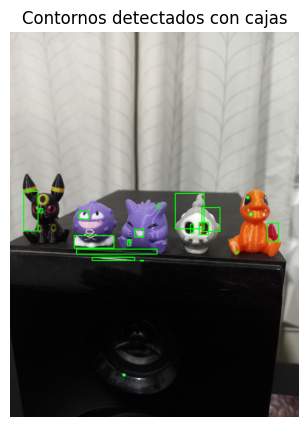

Cantidad de contornos detectados: 542
Cantidad de contornos filtrados: 20
Áreas filtradas: [254.5, 124.5, 366.0, 100.5, 1079.5, 119.5, 153.5, 102.5, 117.5, 154.5]


In [17]:
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
resultado = img.copy()

# Grosor proporcional al tamaño de la imagen (se calcula una sola vez)
alto, ancho = img.shape[:2]
grosor = max(2, ancho // 300)

areas = []
for c in contornos:
    area = cv2.contourArea(c)
    if area > 100:  # filtra contornos pequeños
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(resultado, (x, y), (x+w, y+h), (0, 255, 0), grosor)
        areas.append(area)

mostrar(resultado, "Contornos detectados con cajas")
print("Cantidad de contornos detectados:", len(contornos))
print("Cantidad de contornos filtrados:", len(areas))
print("Áreas filtradas:", areas[:10])

## 9. Guardar y descargar evidencias
Guarda las imágenes generadas para incluirlas en el informe final.

In [ ]:
carpeta = Path("resultados_opencv")
carpeta.mkdir(exist_ok=True)

archivos = {
    "01_original.png": img,
    "02_gris.png": gris,
    "03_redimensionada.png": redimensionada,
    "04_recorte.png": recorte,
    "05_blur_gaussiano.png": blur_gaussiano,
    "06_umbral.png": umbral,
    "07_bordes.png": bordes,
    "08_contornos.png": resultado,
}

for nombre, imagen in archivos.items():
    cv2.imwrite(str(carpeta / nombre), imagen)

print("Archivos guardados en:", carpeta.resolve())
print(list(carpeta.iterdir()))

Archivos guardados en: /content/resultados_opencv
[PosixPath('resultados_opencv/04_recorte.png'), PosixPath('resultados_opencv/06_umbral.png'), PosixPath('resultados_opencv/07_bordes.png'), PosixPath('resultados_opencv/02_gris.png'), PosixPath('resultados_opencv/03_redimensionada.png'), PosixPath('resultados_opencv/01_original.png'), PosixPath('resultados_opencv/05_blur_gaussiano.png'), PosixPath('resultados_opencv/08_contornos.png')]


In [ ]:
# En Google Colab, puedes comprimir y descargar los resultados.
!zip -r resultados_opencv.zip resultados_opencv

try:
    from google.colab import files
    files.download("resultados_opencv.zip")
except Exception as e:
    print("Descarga directa no disponible fuera de Colab:", e)

  adding: resultados_opencv/ (stored 0%)
  adding: resultados_opencv/04_recorte.png (deflated 13%)
  adding: resultados_opencv/06_umbral.png (deflated 34%)
  adding: resultados_opencv/07_bordes.png (deflated 34%)
  adding: resultados_opencv/02_gris.png (deflated 1%)
  adding: resultados_opencv/03_redimensionada.png (deflated 2%)
  adding: resultados_opencv/01_original.png (deflated 14%)
  adding: resultados_opencv/05_blur_gaussiano.png (deflated 9%)
  adding: resultados_opencv/08_contornos.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Mini reto individual o por parejas
Elige una imagen diferente y repite el flujo:

1. Cargar imagen.
2. Mostrar forma, tipo de dato y píxel central.
3. Convertir a gris.
4. Aplicar al menos un filtro.
5. Aplicar Canny o umbralización.
6. Detectar contornos o regiones.
7. Guardar resultados.
8. Explicar qué operación fue más útil y por qué.

## 11. Estructura sugerida para el informe PDF

**Extensión mínima:** 2 páginas.

1. **Portada:** nombre, CADI, semana y fecha.  
2. **Objetivo:** qué se buscó hacer con OpenCV.  
3. **Desarrollo:** código breve, capturas y resultados por ejercicio.  
4. **Análisis:** explicación de lo observado en cada transformación.  
5. **Conclusiones:** aprendizajes, dificultades y recomendaciones.  

**Recuerda:** no basta con pegar capturas. Debes explicar qué hizo cada operación y qué información permitió observar.